In [40]:
#Noor 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

C:\Users\Noort\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Noort\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Q: How well is Olist’s shipping partner performing in terms of timeliness, cost, reliability, and service quality?

In [2]:
orders =pd.read_csv("olist_orders_dataset_cleaned.csv")

In [3]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [4]:
orders[["order_delivered_customer_date","order_estimated_delivery_date"]].isnull().sum()

order_delivered_customer_date    2956
order_estimated_delivery_date       0
dtype: int64

In [5]:
orders.shape
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99229 entries, 0 to 99228
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99229 non-null  str  
 1   customer_id                    99229 non-null  str  
 2   order_status                   99229 non-null  str  
 3   order_purchase_timestamp       99229 non-null  str  
 4   order_approved_at              99083 non-null  str  
 5   order_delivered_carrier_date   97448 non-null  str  
 6   order_delivered_customer_date  96273 non-null  str  
 7   order_estimated_delivery_date  99229 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [6]:
## Explore the order status

In [7]:
orders["order_status"].value_counts()

order_status
delivered      96267
shipped         1106
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [8]:
## filter the data (delivered) only 

In [9]:
delivered = orders[orders["order_status"] == "delivered"].copy()

In [10]:
delivered.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [11]:
orders.dtypes

order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

In [12]:
# so , we need to amke the type datetime

In [13]:
orders['order_purchase_timestamp']= pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at']= pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date']= pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date']= pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date']= pd.to_datetime(orders['order_estimated_delivery_date'])

In [14]:
delivered = orders[orders["order_status"] == "delivered"].copy()
# check again :
print(delivered["order_delivered_customer_date"].isna().sum()) 

0


#### 1- Time

In [15]:
# calculate the diffrent :
delivered["delivery_days"] = (delivered["order_delivered_customer_date"]- delivered["order_purchase_timestamp"]).dt.days

In [16]:
delivered["delivery_days"].mean()

12.103109061256713

In [17]:
delivered.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2


In [20]:
# dt.normalize() , if there is same date but different time , order_estimated_delivery_date there no hours !
delivered["status"]= np.where(delivered["order_delivered_customer_date"].dt.normalize() > delivered["order_estimated_delivery_date"].dt.normalize(),"Delay","On Time")

In [21]:
print(delivered["status"].value_counts())

#count the percentage :
print(delivered["status"].value_counts(normalize=True) * 100)

status
On Time    89736
Delay       6531
Name: count, dtype: int64
status
On Time    93.215744
Delay       6.784256
Name: proportion, dtype: float64


In [22]:
# by these percentage , plot a bar chart :

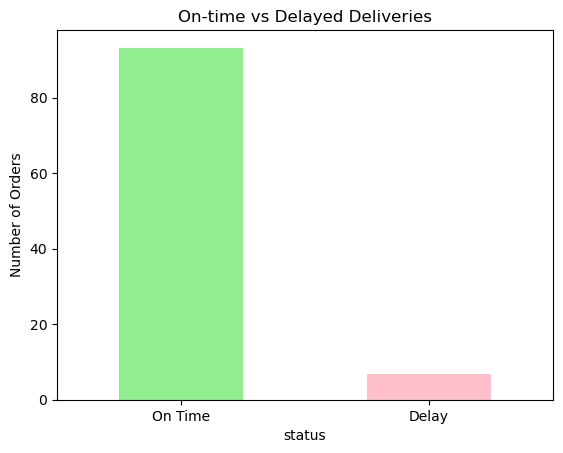

In [23]:
(delivered["status"].value_counts(normalize=True) * 100).plot(kind="bar", color=["lightgreen", "pink"])
plt.title("On-time vs Delayed Deliveries")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

In [41]:
# calc the diffrence between dilvered customer date , and estimated date 

In [42]:
delivered["delivery_difference"]  =(delivered["order_delivered_customer_date"].dt.normalize()
   - delivered["order_estimated_delivery_date"].dt.normalize()).dt.days

In [43]:
# if it with minus then its on time , otherwise it is delay

In [44]:
delivered["delivery_difference"].describe()

count    96267.000000
mean       -11.865364
std         10.180969
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_difference, dtype: float64

In [45]:
# because most of the delivery on time

In [46]:
#the max is 188 !!!
extreme_delay= delivered[delivered["delivery_difference"] > 100]

print("Number of orders:", len(extreme_delay))
print("Percentage:",round(len(extreme_delay) / len(delivered) * 100, 2))

Number of orders: 39
Percentage: 0.04


In [47]:
# filter , only the delay 
delay_days = delivered[delivered["delivery_difference"] > 0]["delivery_difference"]

In [48]:
delay_days.describe()

count    6531.000000
mean       10.623029
std        14.647611
min         1.000000
25%         3.000000
50%         7.000000
75%        13.000000
max       188.000000
Name: delivery_difference, dtype: float64

In [49]:
# median : 7 days , 75% of tha data : 13 days , mean: 10.6 days 

#### 2- cost 

use olist_order_items_dataset to take the 

In [50]:
item=pd.read_csv("olist_order_items_dataset_cleaned.csv")

In [51]:
item.head()

,Unnamed: 0,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [52]:
# we need , to count the ratio:
item[["price", "freight_value"]].head()

,price,freight_value
0,58.90,13.29
1,239.90,19.93
2,199.00,17.87
3,12.99,12.79
4,199.90,18.14


In [53]:
#extra

In [54]:
item = item.drop(columns=["Unnamed: 0"])

In [55]:
# calc the ratio 

In [56]:
item["freight_ratio"] = item["freight_value"] / item["price"]

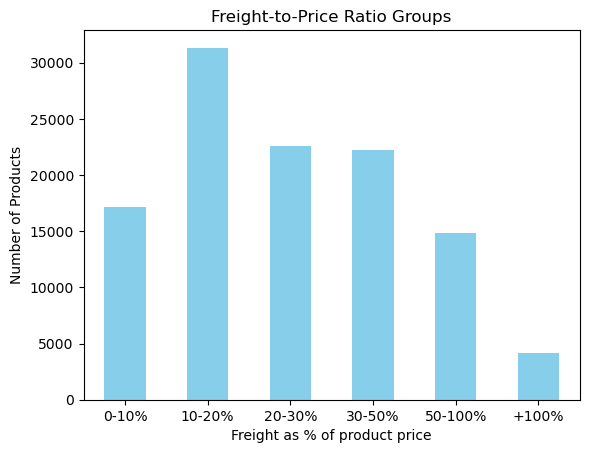

In [57]:
item["ratio_group"]= pd.cut(item["freight_ratio"],bins=[0, 0.1, 0.2, 0.3, 0.5, 1, float("inf")],labels=["0-10%", "10-20%", "20-30%", "30-50%", "50-100%", "+100%"])

groups=(item["ratio_group"].value_counts().sort_index()).plot(kind="bar",color="skyblue")
plt.title("Freight-to-Price Ratio Groups")
plt.xlabel("Freight as % of product price")
plt.ylabel("Number of Products")
plt.xticks(rotation=0)
plt.show()

In [58]:
item["freight_ratio"].describe()

count    112646.000000
mean          0.320860
std           0.349897
min           0.000000
25%           0.134031
50%           0.231356
75%           0.393036
max          26.235294
Name: freight_ratio, dtype: float64

In [59]:
item["freight_value"].mean()

19.989678284182304

In [60]:
## mean is 32% of item price , Shipping typically costs about 23% of the product price (median), while the average is 32% because a few low-priced
#items have very high shipping costs

In [61]:
# Free delivery :
print((item["freight_value"]==0).mean()* 100)

0.34000319585249367


In [64]:
# to find the price for free delivery :
free = item[item["freight_value"] == 0]
print(free["price"].describe())

count    383.000000
mean      98.601488
std       50.004247
min       53.900000
25%       69.900000
50%       99.900000
75%      106.900000
max      712.900000
Name: price, dtype: float64


#### 3- Reliability 

In [65]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [66]:
# order_status column
orders["order_status"].value_counts(normalize=True)*100

order_status
delivered      97.014986
shipped         1.114594
canceled        0.629856
unavailable     0.613732
invoiced        0.316440
processing      0.303339
created         0.005039
approved        0.002016
Name: proportion, dtype: float64

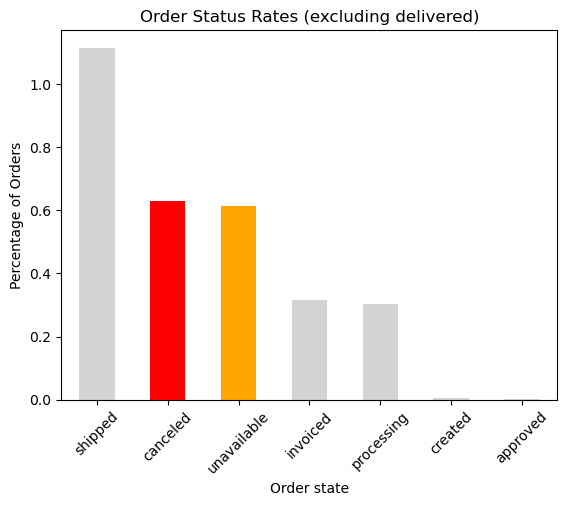

In [67]:
(orders["order_status"].value_counts(normalize=True) * 100).drop("delivered").plot(kind="bar", color= ["lightgray", "red", "orange", "lightgray", "lightgray", "lightgray", "lightgray"])
plt.title("Order Status Rates (excluding delivered)")
plt.ylabel("Percentage of Orders")
plt.xlabel("Order state")
plt.xticks(rotation=45)


plt.show()

In [68]:
## Reliability is high: 1.24% of orders were canceled or unavailable, and only 0.36% of delivered orders arrived more than 30 days late.

In [46]:
# more than one month :
severe = delivered["delivery_difference"] > 30
print(severe.sum())
print(severe.mean() * 100)

345
0.358378260463087


### Reviewd

In [71]:
review=pd.read_csv("olist_order_reviews_dataset_cleaned.csv")

In [72]:
review.head()

,review_id,order_id,review_score,review_comment_title,review_comment_title_english,review_comment_message,review_comment_message_english,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,NaN,Recebi bem antes do prazo estipulado.,I received it well before the stipulated time.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,NaN,Parabéns lojas lannister adorei comprar pela I...,Congratulations Lannister stores I loved shopp...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [73]:
review["review_score"].describe()

count    99224.000000
mean         4.086421
std          1.347579
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: review_score, dtype: float64

In [74]:
# for more than review each order :
print(len(review) - review["order_id"].nunique())  

551


In [75]:
#so we clean the review to see if there is any diffrent :
clean_review= review.drop_duplicates(subset="order_id", keep="last")
print((clean_review["review_score"].value_counts(normalize=True).sort_index() * 100).round(2))

review_score
1    11.51
2     3.17
3     8.24
4    19.30
5    57.78
Name: proportion, dtype: float64


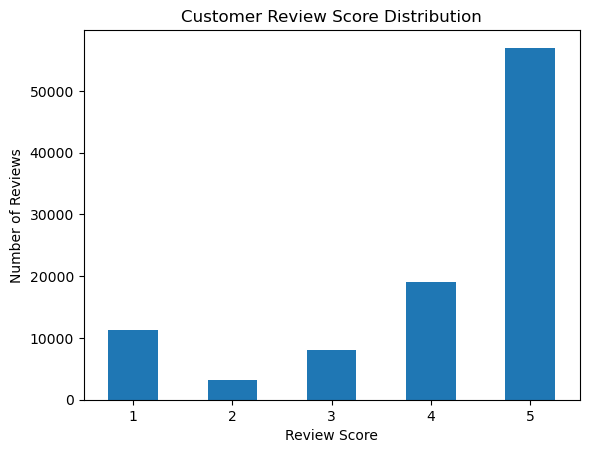

In [76]:
clean_review["review_score"].value_counts().sort_index().plot( kind="bar")

plt.title("Customer Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.show()

In [77]:
low= review[review["review_score"]>= 4]
print(low["review_comment_message_english"].dropna().head(20))

3        I received it well before the stipulated time.
4     Congratulations Lannister stores I loved shopp...
9     efficient device. on the website the brand of ...
12    But a little slowing down...for the price it's...
15    Reliable seller, ok product and delivery on time.
22                                        store note 10
24                 thanks for the attention given to me
27    The purchase was made easily.\r\nDelivery was ...
28                           very nice and cheap watch.
34    I received exactly what I expected. Other orde...
36                                        I recommend ,
37                                            very good
38    I'm completely in love, super responsible and ...
43                            Very good. very fragrant.
47    great seller arrived before the deadline, I lo...
49               Smooth and efficient purchase process.
50                  I hope it lasts because it's furry.
55                                              

# Q3 

In [78]:
customers=pd.read_csv("olist_customers_dataset_cleaned.csv")

In [79]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,state_name
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,Sao Paulo
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,Sao Paulo
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,Sao Paulo
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,Sao Paulo
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,Sao Paulo


In [80]:
#### sellers for each order :
sellers = pd.read_csv("olist_sellers_dataset_cleaned.csv")
print(sellers["seller_state_name"].value_counts().head(10))

seller_state_name
Sao Paulo            1849
Parana                349
Minas Gerais          244
Santa Catarina        190
Rio de Janeiro        171
Rio Grande do Sul     129
Goias                  40
Federal District       30
Espirito Santo         23
Bahia                  19
Name: count, dtype: int64


In [89]:
state_d=delivered.merge(customers[["customer_id", "customer_state", "state_name"]],on="customer_id", how="left")


In [90]:
state_d["is_late"] = state_d["status"] == "Delay" 


In [91]:
items_sellers = item.merge(sellers[["seller_id", "seller_state"]], on="seller_id", how="left")
order_seller = items_sellers.drop_duplicates(subset="order_id", keep="first")[["order_id", "seller_state"]]

In [92]:
#amother merge :
state_d = state_d.merge(order_seller, on="order_id", how="left")

In [92]:
item_state= item.merge(state_d[["order_id", "state_name"]],  on="order_id",how="left")

item_state.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,freight_ratio,ratio_group,state_name
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,0.225637,20-30%,Rio de Janeiro
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,0.083076,0-10%,Sao Paulo
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,0.089799,0-10%,Minas Gerais
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,0.984604,50-100%,Sao Paulo
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,0.090745,0-10%,Sao Paulo


## Q4 
Is the shipping partner meeting expectations for on-time delivery and fair pricing?

In [96]:
# we solved from Q2 , on time delivery  , based on set 3 Q 2, 3 , 4 also

In [97]:
item["freight_ratio"].describe()

count    112646.000000
mean          0.320860
std           0.349897
min           0.000000
25%           0.134031
50%           0.231356
75%           0.393036
max          26.235294
Name: freight_ratio, dtype: float64

In [98]:
high_shipping=item[item["freight_ratio"]>1]

In [99]:
high_shipping.describe()

,order_item_id,price,freight_value,freight_ratio
count,4124.000000,4124.000000,4124.000000,4124.000000
mean,1.433075,17.623378,24.332825,1.514666
std,1.216601,15.994419,22.651010,0.914294
min,1.000000,0.850000,7.390000,1.000500
25%,1.000000,10.500000,15.100000,1.111429
50%,1.000000,13.900000,18.230000,1.279000
75%,1.000000,18.900000,25.630000,1.611395
max,20.000000,189.900000,299.160000,26.235294


# Set 3 
## Q1: -What is the average freight value, and what percentage of the total product price does it represent?

In [100]:
# take the average for freight value
item["freight_value"].describe()

count    112646.000000
mean         19.989678
std          15.805705
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64

In [101]:
#  percentage of the total product price 
total_freight = item["freight_value"].sum()
total_product_price = item["price"].sum()

In [106]:
# percentage :
print(total_freight/ total_product_price * 100)

16.567640140594843


In [107]:
#Ratio
item["freight_ratio"].describe()

count    112646.000000
mean          0.320860
std           0.349897
min           0.000000
25%           0.134031
50%           0.231356
75%           0.393036
max          26.235294
Name: freight_ratio, dtype: float64

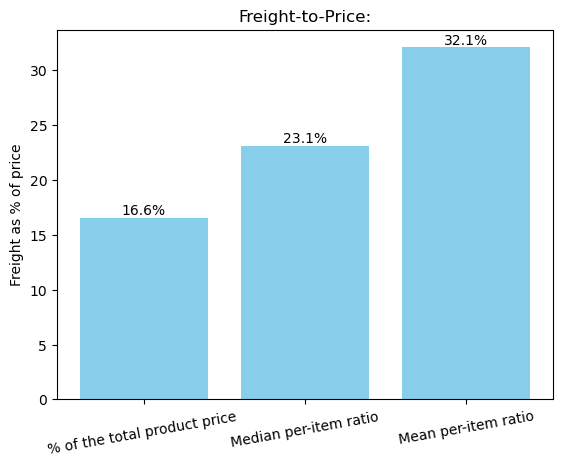

In [108]:
#Create data frame to make plot
vals = {
    "% of the total product price ": total_freight / total_product_price * 100,
    "Median per-item ratio": item["freight_ratio"].median() * 100,
    "Mean per-item ratio": item["freight_ratio"].mean() * 100,}
#plot
Graph = plt.bar(vals.keys(), vals.values(), color="skyblue")
plt.bar_label(Graph, fmt="%.1f%%")
plt.ylabel("Freight as % of price")
plt.xticks(rotation=10)

plt.title("Freight-to-Price:")
plt.show()

##### On average, freight is 19.99 BRL per item, equal to 16.6% of total product value. The median item pays 23% of its price, while the mean is higher (32%) because low-priced items carry proportionally heavy freight.

## Q2
### -How does the freight-to-price ratio vary by product category or state?

In [109]:
products= pd.read_csv("olist_products_dataset_cleaned.csv") 

In [110]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


### By product category 

In [113]:
# merge step: item with products data by id

In [114]:
item_category = item.merge(products[["product_id", "product_category_name"]],on="product_id",how="left")

In [116]:
# make the names of the categories in English
tran=pd.read_csv("product_category_name_translation.csv")

In [117]:
item_category=item_category.merge(tran[["product_category_name", "product_category_name_english"]], on="product_category_name", how="left" )

In [118]:
print(item_category[["price", "freight_value", "freight_ratio"]].head())

    price  freight_value  freight_ratio
0   58.90          13.29       0.225637
1  239.90          19.93       0.083076
2  199.00          17.87       0.089799
3   12.99          12.79       0.984604
4  199.90          18.14       0.090745


In [119]:
# for each category 
category_ratio = (item_category.groupby("product_category_name")["freight_ratio"].mean()* 100)
category_ratio = category_ratio.sort_values(ascending=False)
print(category_ratio)

product_category_name
casa_conforto_2                   93.386243
dvds_blu_ray                      83.304467
eletronicos                       68.351661
artigos_de_natal                  67.565952
fashion_underwear_e_moda_praia    56.550343
                                    ...    
relogios_presentes                17.058094
portateis_casa_forno_e_cafe       16.434979
seguros_e_servicos                14.754843
pc_gamer                           9.655630
pcs                                5.661292
Name: freight_ratio, Length: 74, dtype: float64


In [120]:
# another way by mean value/mean price
cat = item_category.groupby("product_category_name_english").agg(items=("order_id", "count"),freight=("freight_value", "sum"),price=("price", "sum")
 ,freight_mean =("freight_value", "median"),price_mean =("price", "median"))
cat["freight_ratio"] = (cat["freight"] / cat["price"]).round(3)*100
cat.sort_values(by="freight_ratio", ascending=False)

,items,freight,price,freight_mean,price_mean,freight_ratio
product_category_name_english,,,,,,
home_comfort_2,30,410.31,760.27,15.10,12.900,54.0
flowers,33,488.87,1110.04,16.11,25.990,44.0
furniture_mattress_and_upholstery,38,1630.46,4368.08,38.97,85.000,37.3
christmas_supplies,153,3229.30,8800.82,17.92,44.900,36.7
diapers_and_hygiene,39,573.68,1567.59,12.92,37.000,36.6
...,...,...,...,...,...,...
watches_gifts,5991,100535.93,1205005.68,15.82,129.000,8.3
agro_industry_and_commerce,212,5843.60,72530.47,23.68,258.650,8.1
fixed_telephony,264,4637.81,59583.00,15.10,64.485,7.8


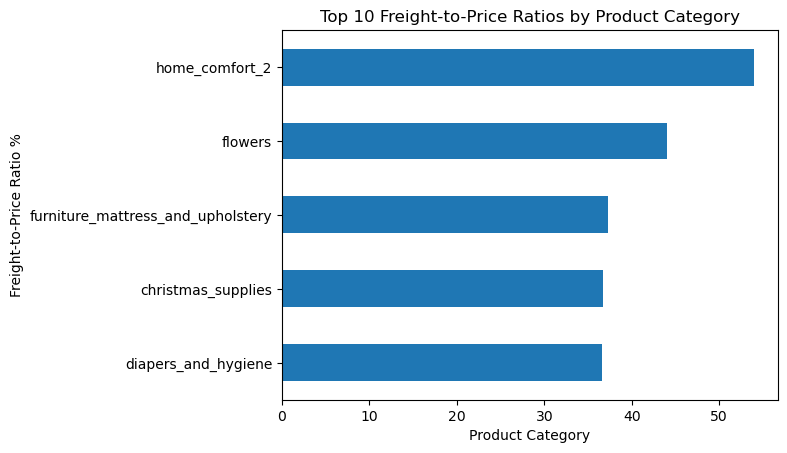

In [121]:
cat.sort_values(by="freight_ratio").tail(5)["freight_ratio"].plot(kind="barh")
plt.title("Top 10 Freight-to-Price Ratios by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Freight-to-Price Ratio %")
plt.xticks(rotation=0)

plt.show()

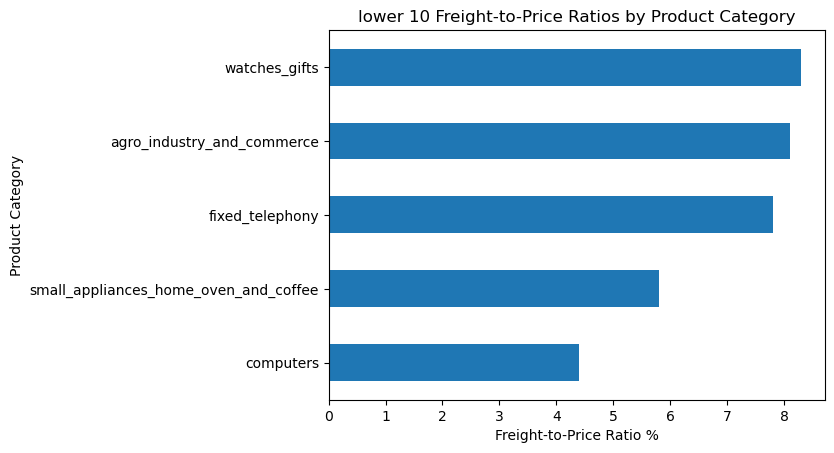

In [122]:
cat.sort_values(by="freight_ratio").head(5)["freight_ratio"].plot(kind="barh")
plt.title("lower 10 Freight-to-Price Ratios by Product Category")
plt.ylabel("Product Category")
plt.xlabel("Freight-to-Price Ratio %")
plt.xticks(rotation=0)
plt.show()

## By states

In [128]:
#merge the id 
item_state=item.merge(orders[["order_id","customer_id"]],on="order_id",how="left")

In [129]:
# merge the customers state :
item_state = item_state.merge(customers[["customer_id","state_name"]], on="customer_id" , how="left")

In [130]:
# make data frame :
state=item_state.groupby("state_name").agg(items=("order_id", "count"),freight=("freight_value","sum"),price=("price", "sum"),freight_mean=("freight_value", "mean"),
price_mean=("price", "mean"))

In [131]:
# calc the ratio by state:
state["freight_ratio"]= (state["freight"] /state["price"]).round(3) * 100

In [132]:
state.sort_values(by="freight_ratio", ascending=False).head(10)

,items,freight,price,freight_mean,price_mean,freight_ratio
state_name,,,,,,
Roraima,52,2235.19,7829.43,42.984423,150.565962,28.5
Maranhao,820,31368.72,119443.65,38.254537,145.662988,26.3
Rondonia,278,11417.38,46140.64,41.069712,165.973525,24.7
Amazonas,165,5478.89,22356.84,33.205394,135.496000,24.5
Piaui,539,21066.06,86641.18,39.083599,160.744304,24.3
Sergipe,384,14088.20,58842.85,36.688021,153.236589,23.9
Tocantins,314,11629.56,49441.84,37.036815,157.458089,23.5
Acre,92,3686.75,15982.95,40.073370,173.727717,23.1
Rio Grande do Norte,529,18860.10,83034.98,35.652363,156.965936,22.7


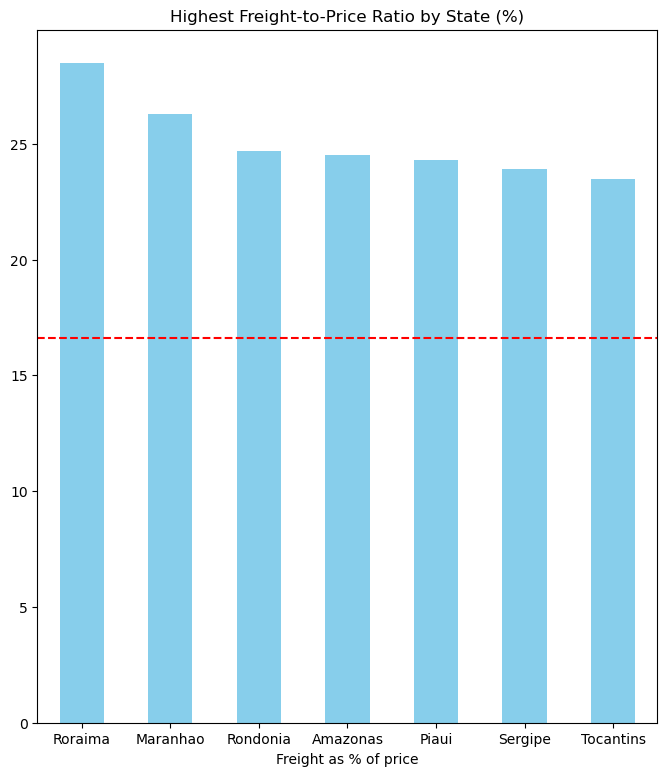

In [133]:
plot_state = state.drop("international")["freight_ratio"].sort_values(ascending=False).head(7).plot(kind="bar", color="skyblue", figsize=(8, 9))
plt.axhline(16.6, color="red", linestyle="--")
plt.title("Highest Freight-to-Price Ratio by State (%)")
plt.xlabel("Freight as % of price")
plt.xticks(rotation=0)

plt.show()

## Q3
Are lighter products being overcharged (e.g., low weight but high freight)

In [134]:
# merged item with weight
item_weight = item.merge(products[["product_id", "product_weight_g"]], on="product_id", how="left")

In [135]:
print(item_weight["product_weight_g"].isna().sum())     
print((item_weight["product_weight_g"] == 0).sum())      

18
8


In [136]:
# filter the data :
item_weight=item_weight[item_weight["product_weight_g"] > 0].copy()
len(item_weight)

112620

In [137]:
# to find max , min of weight
item_weight["product_weight_g"].describe()

count    112620.000000
mean       2093.550169
std        3751.346883
min           2.000000
25%         300.000000
50%         700.000000
75%        1800.000000
max       40425.000000
Name: product_weight_g, dtype: float64

In [138]:
# make group for weight :
item_weight["weight_group"] = pd.cut(item_weight["product_weight_g"], bins=[0, 300, 700, 1800, 5000, float("inf")], labels=["<300g", "300-700g", "700-1800g", "1800-5000g", ">5000g"])


In [139]:
print(item_weight["weight_group"].value_counts().sort_index())

weight_group
<300g         31741
300-700g      26261
700-1800g     26858
1800-5000g    13871
>5000g        13889
Name: count, dtype: int64


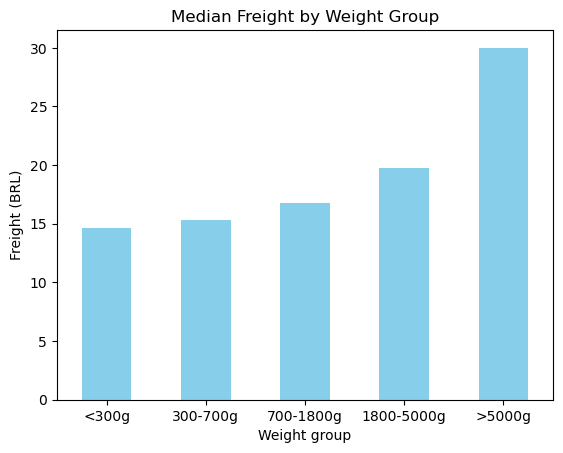

In [169]:
item_weight.groupby("weight_group", observed=True)["freight_value"].median().plot(kind="bar", color="skyblue")
plt.title("Median Freight by Weight Group")
plt.xlabel("Weight group")
plt.ylabel("Freight (BRL)")
plt.xticks(rotation=0)
plt.show()

# Q4 
How does distance between seller and customer impact freight value and delay?

In [142]:
geolocation=pd.read_csv("olist_geolocation_dataset_cleaned.csv")

In [143]:
# for each zip code:
geo = geolocation.groupby("geolocation_zip_code_prefix").agg( latitude=("geolocation_lat", "mean"),longitude=("geolocation_lng", "mean")).reset_index()

In [144]:
seller_location = sellers.merge(geo,left_on="seller_zip_code_prefix",right_on="geolocation_zip_code_prefix",how="left")

In [145]:
item_seller = item.merge(sellers[["seller_id", "seller_zip_code_prefix"]], on="seller_id", how="left")
# every order : not every item
order_seller_zip = item_seller.drop_duplicates(subset="order_id", keep="first")[["order_id", "seller_zip_code_prefix"]]

In [146]:
#add customer zip code in delirved dataframe
dist= delivered[["order_id", "customer_id", "status"]].merge(customers[["customer_id", "customer_zip_code_prefix"]], on="customer_id",how="left")

In [147]:
dist = dist.merge(order_seller_zip, on="order_id", how="left")

In [148]:
#except international
geo= geolocation[geolocation["state_name"] != "international"]
location= geo.groupby("geolocation_zip_code_prefix")[["geolocation_lat", "geolocation_lng"]].median()

In [149]:
# rename
cust_location= location.rename(columns={"geolocation_lat": "cust_lat", "geolocation_lng": "cust_lng"})

In [150]:
# merge with the customer:
dist = dist.merge(cust_location, left_on="customer_zip_code_prefix", right_index=True, how="left")

In [151]:
# then , the location of sellers : rename to be diffrent col
sell_location= location.rename(columns={"geolocation_lat": "sell_lat", "geolocation_lng": "sell_lng"})

In [152]:
# then , merge them :
dist = dist.merge(sell_location,left_on="seller_zip_code_prefix", right_index=True, how="left")

In [153]:
# convert them to  radius:
lat_cust= np.radians(dist["cust_lat"])
lng_cust= np.radians(dist["cust_lng"])
lat_sell= np.radians(dist["sell_lat"])
lng_sell= np.radians(dist["sell_lng"])

In [154]:
#Haversine formula from google:
km=np.sin((lat_sell - lat_cust) / 2) ** 2 + np.cos(lat_cust) * np.cos(lat_sell) * np.sin((lng_sell - lng_cust) / 2) ** 2
dist["distance_km"]= 2 * 6371 * np.arcsin(np.sqrt(km))

In [155]:
# grouping the distance:
dist["distance_group"]=pd.cut(dist["distance_km"], bins=[-1, 100, 300, 700, 1500, float("inf")], labels=["<100km", "100-300km", "300-700km", "700-1500km", ">1500km"])

In [156]:
# before merge the price - value :
totalcost=item.groupby("order_id").agg(freight_value=("freight_value", "sum"),price=("price", "sum"))

In [157]:
dist=dist.merge(totalcost,on="order_id",how="left")

In [158]:
dist_freight = dist.groupby("distance_group")["freight_value"].mean()
dist_freight

distance_group
<100km        13.451824
100-300km     18.747591
300-700km     22.718233
700-1500km    26.443569
>1500km       39.886903
Name: freight_value, dtype: float64

In [159]:
#Freight rises steadily with distance: orders under 100 km pay an average of 13.45 BRL versus 39.89 BRL beyond 1,500 km, almost three times as much.

In [160]:
dist_delay =(dist.groupby("distance_group")["status"].apply(lambda x: (x == "Delay").mean() * 100))
dist_delay

distance_group
<100km         4.455390
100-300km      5.194513
300-700km      6.963534
700-1500km     7.416038
>1500km       11.655811
Name: status, dtype: float64

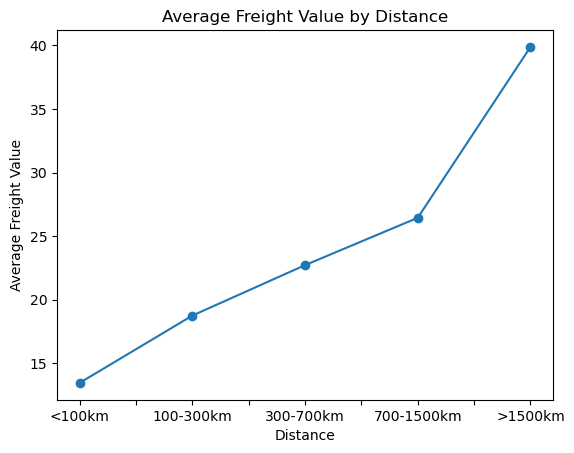

In [161]:
# plot for dist and freight value 
dist_freight.plot(kind="line", marker="o")
plt.title("Average Freight Value by Distance")
plt.xlabel("Distance")
plt.ylabel("Average Freight Value")
plt.xticks(rotation=0)
plt.show()

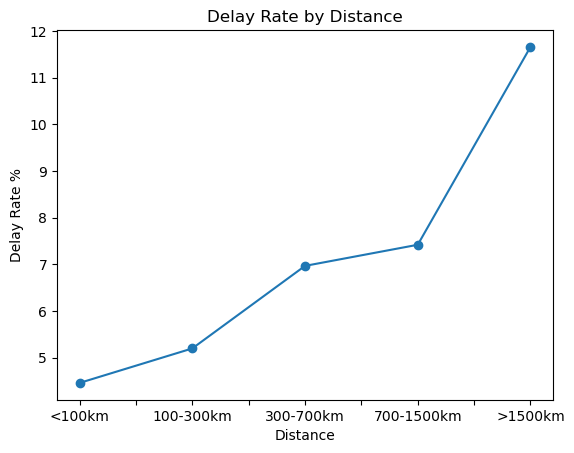

In [162]:
# plot between dist and delay
dist_delay.plot(kind="line", marker="o")
plt.title("Delay Rate by Distance")
plt.xlabel("Distance")
plt.ylabel("Delay Rate %")
plt.xticks(rotation=0)
plt.show()

In [163]:
## Both freight and delay rise with distance: orders under 100 km pay 13.45 BRL on average with a 4.5% delay rate, versus 39.89 BRL and 11.7% beyond
# 1,500 km. Distance explains part of the delay, but not all of it: some Northeastern states exceed the delay rate of the farthest distance group

# Q5
Is the underestimation of delivery time or cost a frequent issue, and why does it occur?

In [164]:
# the different between purchase date and estimate date
delivered["orders_days"]=(delivered["order_estimated_delivery_date"]- delivered["order_purchase_timestamp"]).dt.days

In [165]:
# Take the median if there any out of range values :
# estimate range
print( "median promised=", delivered["orders_days"].median())
# real range
print("median actual=",delivered["delivery_days"].median())

median promised= 23.0
median actual= 10.0


In [166]:
diffrent= {"Actual Delivery":delivered["delivery_days"].median(), 
           "Estimated Delivery":delivered["orders_days"].median()}

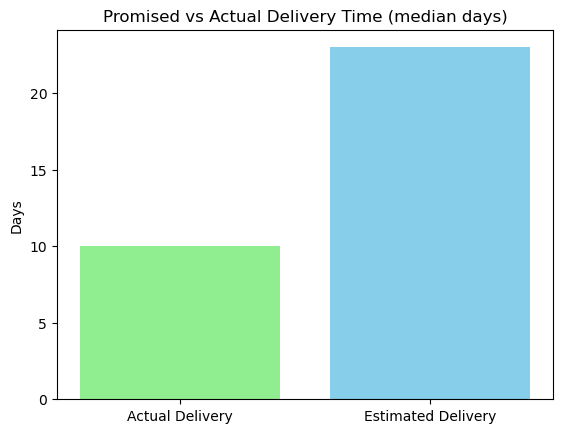

In [167]:
plt.bar(diffrent.keys(),diffrent.values(), color=["lightgreen", "skyblue"])
plt.title("Promised vs Actual Delivery Time (median days)")
plt.ylabel("Days")
plt.show()